In [2]:
import os
print(os.path.abspath("../data/raw/car-prices.csv"))

c:\Users\mouss\Desktop\studies\projects\car-price-prediction\data\raw\car-prices.csv


In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv("../data/raw/car-prices.csv")
print(df.head())
print(df.shape)

                       name    year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007.0          60000    70000.0  Petrol   
1  Maruti Wagon R LXI Minor  2007.0         135000    50000.0  Petrol   
2      Hyundai Verna 1.6 SX  2012.0         600000   100000.0  Diesel   
3    Datsun RediGO T Option  2017.0         250000    46000.0  Petrol   
4     Honda Amaze VX i-DTEC  2014.0         450000   141000.0  Diesel   

  seller_type transmission         owner  
0  Individual       Manual   First Owner  
1  Individual       Manual           NaN  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  
(4340, 8)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4340 non-null   str    
 1   year           4297 non-null   float64
 2   selling_price  4340 non-null   int64  
 3   km_driven      4167 non-null   float64
 4   fuel           4254 non-null   str    
 5   seller_type    4275 non-null   str    
 6   transmission   4340 non-null   str    
 7   owner          4254 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 271.4 KB


In [5]:
print(df.dtypes)

name                 str
year             float64
selling_price      int64
km_driven        float64
fuel                 str
seller_type          str
transmission         str
owner                str
dtype: object


In [6]:
df['owner'].value_counts()

owner
First Owner             2771
Second Owner            1084
Third Owner              302
Fourth & Above Owner      80
Test Drive Car            17
Name: count, dtype: int64

In [7]:
print(df.notna().sum())

name             4340
year             4297
selling_price    4340
km_driven        4167
fuel             4254
seller_type      4275
transmission     4340
owner            4254
dtype: int64


In [8]:
print(df.isnull().sum())

name               0
year              43
selling_price      0
km_driven        173
fuel              86
seller_type       65
transmission       0
owner             86
dtype: int64


In [9]:
print(df.describe())

              year  selling_price      km_driven
count  4297.000000   4.340000e+03    4167.000000
mean   2013.087736   5.041273e+05   66237.198224
std       4.219918   5.785487e+05   46635.456187
min    1992.000000   2.000000e+04       1.000000
25%    2011.000000   2.087498e+05   35000.000000
50%    2014.000000   3.500000e+05   60000.000000
75%    2016.000000   6.000000e+05   90000.000000
max    2020.000000   8.900000e+06  806599.000000


In [10]:
df.drop(columns=["name"])
print(df.columns)

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='str')


In [11]:
print(df.duplicated().sum())

635


In [12]:
df.drop_duplicates(inplace=True)

In [13]:
print(df.duplicated().sum())

0


In [14]:
print(df.columns)

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='str')


In [15]:
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    print(f"{col} = {df[col].value_counts()} \n")

fuel = fuel
Diesel      1823
Petrol      1738
CNG           37
LPG           22
Electric       1
Name: count, dtype: int64 

seller_type = seller_type
Individual          2867
Dealer               734
Trustmark Dealer      39
Name: count, dtype: int64 

transmission = transmission
Manual       3378
Automatic     327
Name: count, dtype: int64 

owner = owner
First Owner             2250
Second Owner             988
Third Owner              290
Fourth & Above Owner      74
Test Drive Car            17
Name: count, dtype: int64 



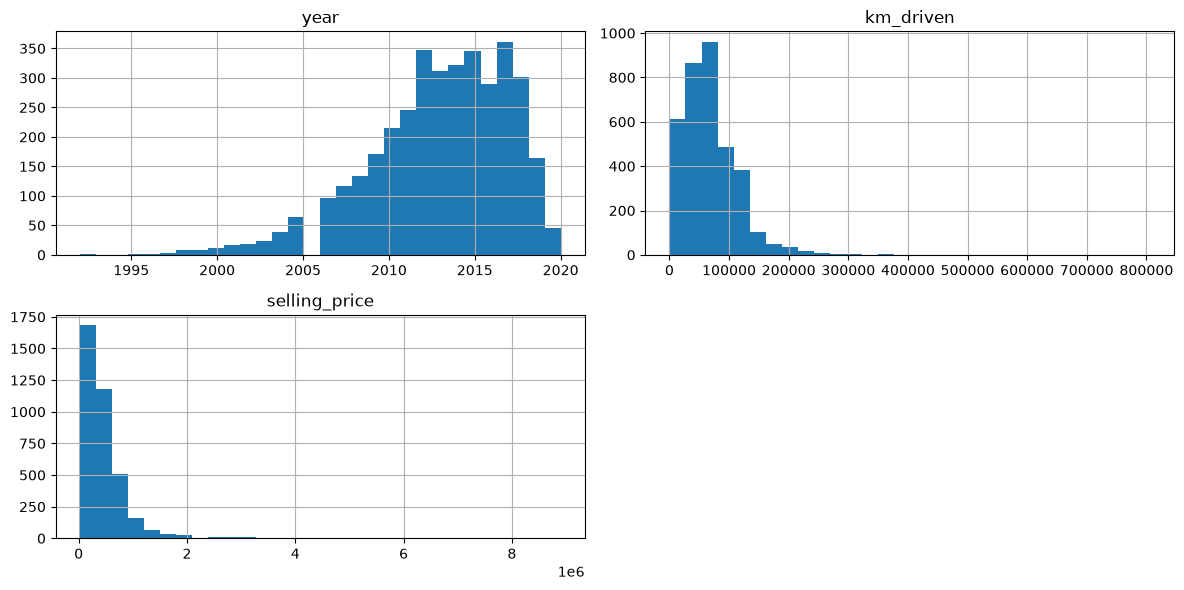

In [16]:
df[['year','km_driven', 'selling_price']].hist(figsize=(12, 6), bins=30)
plt.tight_layout()
plt.show()

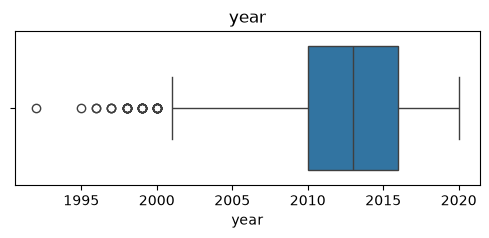

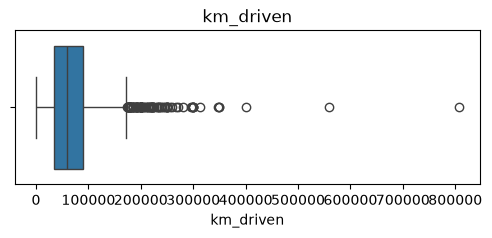

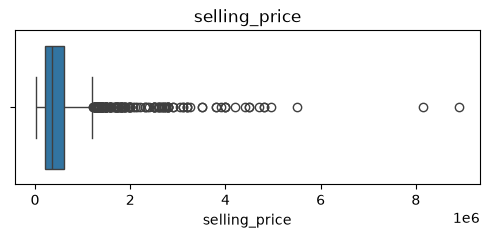

In [17]:
for col in ['year', 'km_driven', 'selling_price']:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

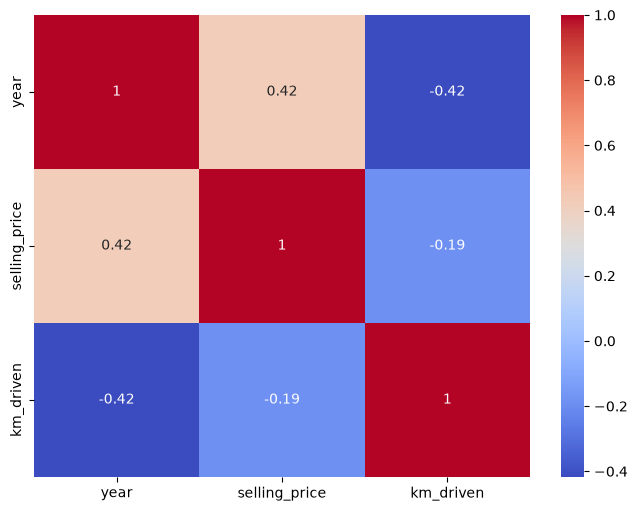

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

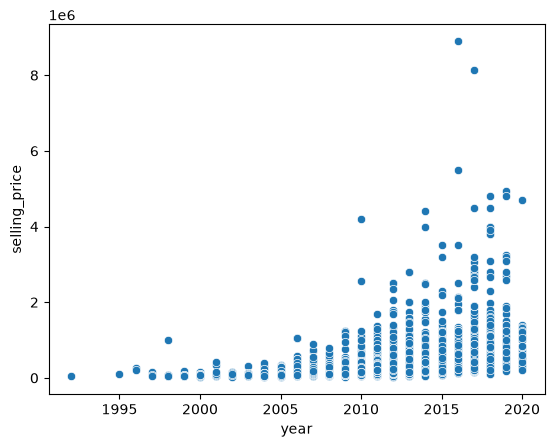

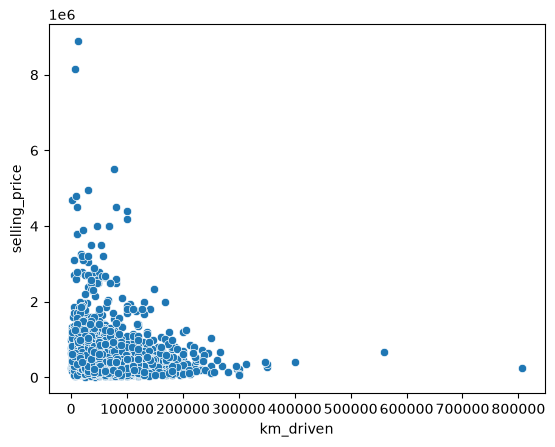

In [19]:
sns.scatterplot(data=df, x='year', y='selling_price')
plt.show()
sns.scatterplot(data=df, x='km_driven', y='selling_price')
plt.show()

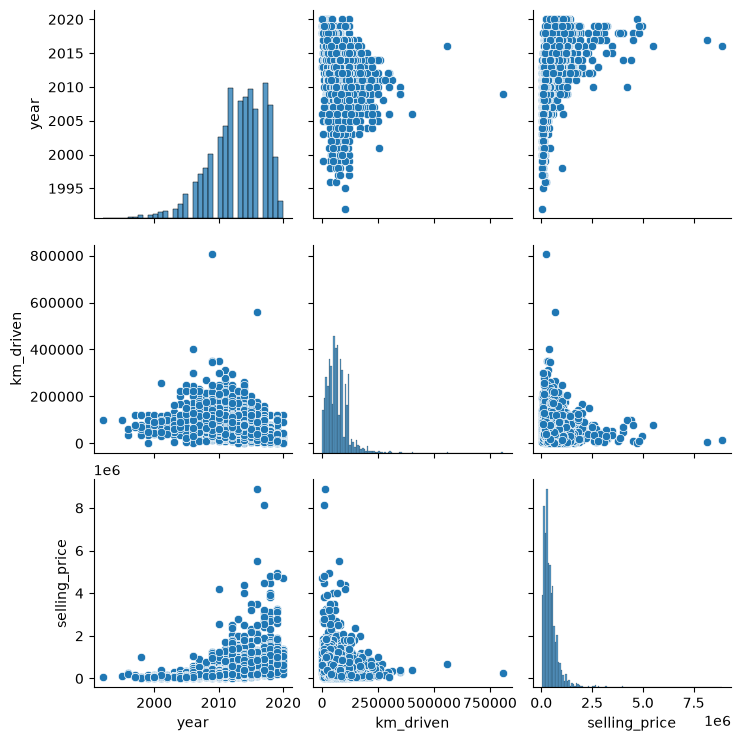

In [20]:
sns.pairplot(df[['year', 'km_driven', 'selling_price']])
plt.show()